# Asymptotic behavior of the linear KF

This brief notebook illustrates the asymptotic behavior of a **discrete-time
linear Kalman filter** for a time-invariant system:

$$
x_{k+1} = A x_k + w_k, \qquad y_k = C x_k + v_k
$$

with Gaussian process and measurement noise:

$$
w_k \sim \mathcal N(0,Q), \qquad v_k \sim \mathcal N(0,R).
$$

Under standard assumptions, the filter tends to a **steady-state regime**:
- the prediction/update covariance converges,
- the Kalman gain converges,
- the estimation error statistics settle.

This is the discrete-time counterpart of the statement that the dependence on the initial condition disappears asymptotically.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

## 1. Model and Kalman filter recursion

We consider a stable 2D system observed through a scalar sensor.


In [10]:
# System matrices
A = np.array([[0.90, 0.20],
              [0.00, 0.85]])
C = np.array([[1.00, 0.00]])

Q = np.array([[0.02, 0.00],
              [0.00, 0.01]])
R = np.array([[0.05]])

n = A.shape[0]
m = C.shape[0]

# Simulation length
T = 80

# True initial state
x0 = np.array([[1.5],
               [-0.8]])

# Filter initialization (intentionally poor)
xhat0 = np.array([[0.0],
                  [0.0]])
P0 = 10.0 * np.eye(n)


In [11]:
# Simulate the true system
x_true = np.zeros((T + 1, n, 1))
y_meas = np.zeros((T + 1, m, 1))

x_true[0] = x0

for k in range(T):
    wk = np.random.multivariate_normal(np.zeros(n), Q).reshape(n, 1)
    vk = np.random.multivariate_normal(np.zeros(m), R).reshape(m, 1)
    y_meas[k] = C @ x_true[k] + vk
    x_true[k + 1] = A @ x_true[k] + wk

# final measurement
vk = np.random.multivariate_normal(np.zeros(m), R).reshape(m, 1)
y_meas[T] = C @ x_true[T] + vk


In [12]:
# Kalman filter recursion
xhat_pred = np.zeros((T + 1, n, 1))
xhat_upd  = np.zeros((T + 1, n, 1))
P_pred = np.zeros((T + 1, n, n))
P_upd  = np.zeros((T + 1, n, n))
K_hist = np.zeros((T + 1, n, m))

xhat_upd[0] = xhat0
P_upd[0] = P0

for k in range(T + 1):
    # innovation at time k
    S = C @ P_upd[k] @ C.T + R
    K = P_upd[k] @ C.T @ np.linalg.inv(S)
    innov = y_meas[k] - C @ xhat_upd[k]

    # update
    xhat_upd[k] = xhat_upd[k] + K @ innov
    P_upd[k] = (np.eye(n) - K @ C) @ P_upd[k]
    K_hist[k] = K

    # predict
    if k < T:
        xhat_pred[k + 1] = A @ xhat_upd[k]
        P_pred[k + 1] = A @ P_upd[k] @ A.T + Q
        xhat_upd[k + 1] = xhat_pred[k + 1]
        P_upd[k + 1] = P_pred[k + 1]

## 2. Covariance convergence

A hallmark of the asymptotic regime is that the covariance converges to a fixed point of the discrete Riccati equation, and the Kalman gain converges to a constant gain.


In [13]:
# Extract some scalar summaries for visualization
P11 = P_upd[:, 0, 0]
P22 = P_upd[:, 1, 1]
K1 = K_hist[:, 0, 0]
K2 = K_hist[:, 1, 0]

print("Last updated covariance P_upd[T] =")
print(P_upd[-1])
print("\nLast Kalman gain K[T] =")
print(K_hist[-1])


Last updated covariance P_upd[T] =
[[0.02269103 0.00518219]
 [0.00518219 0.03249233]]

Last Kalman gain K[T] =
[[0.45382062]
 [0.10364376]]


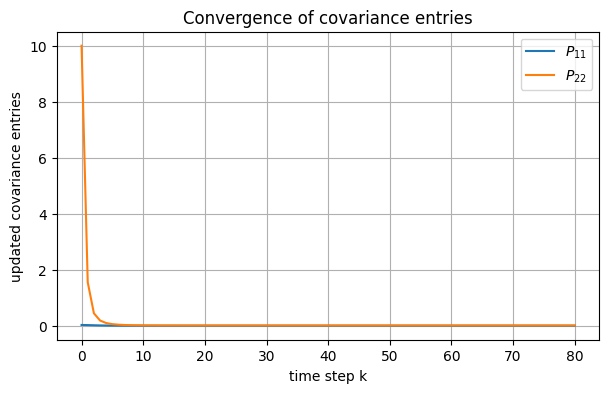

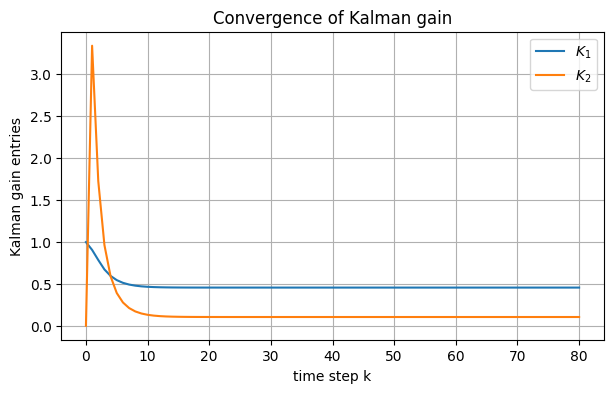

In [14]:
k = np.arange(T + 1)

plt.figure(figsize=(7, 4))
plt.plot(k, P11, label=r"$P_{11}$")
plt.plot(k, P22, label=r"$P_{22}$")
plt.xlabel("time step k")
plt.ylabel("updated covariance entries")
plt.title("Convergence of covariance entries")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(k, K1, label=r"$K_1$")
plt.plot(k, K2, label=r"$K_2$")
plt.xlabel("time step k")
plt.ylabel("Kalman gain entries")
plt.title("Convergence of Kalman gain")
plt.legend()
plt.grid(True)
plt.show()


## 3. Estimation error decay

We now compare the true state and the estimate. Even with a poor initial guess, the filter rapidly forgets the initialization and tracks the state according to the stationary error statistics.


<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_601/3131261302.py:8: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(k, xhat[:, 0], "--", label="estimate $\hat x_1$")


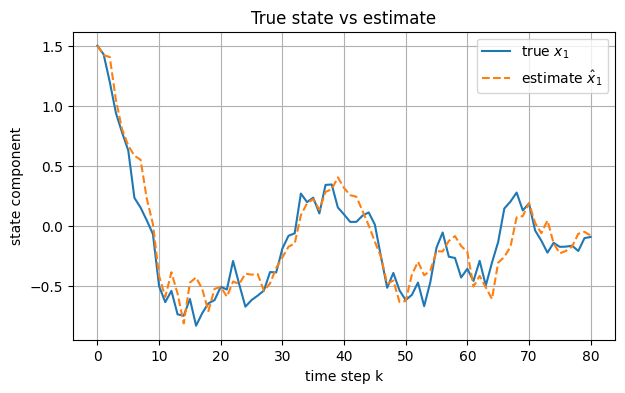

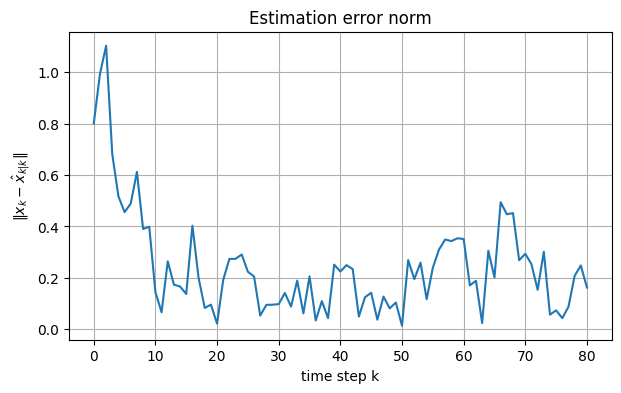

In [15]:
xhat = xhat_upd[:, :, 0]
xtru = x_true[:, :, 0]
err = xtru - xhat
err_norm = np.linalg.norm(err, axis=1)

plt.figure(figsize=(7, 4))
plt.plot(k, xtru[:, 0], label="true $x_1$")
plt.plot(k, xhat[:, 0], "--", label="estimate $\hat x_1$")
plt.xlabel("time step k")
plt.ylabel("state component")
plt.title("True state vs estimate")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(k, err_norm)
plt.xlabel("time step k")
plt.ylabel(r"$\|x_k - \hat x_{k|k}\|$")
plt.title("Estimation error norm")
plt.grid(True)
plt.show()


## 4. Monte Carlo view of asymptotic error covariance

A single trajectory is noisy, so we run many simulations and compare the empirical estimation error covariance at each time with the theoretical covariance produced by the filter recursion.


<>:36: SyntaxWarning: invalid escape sequence '\|'
<>:36: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_601/2270393778.py:36: SyntaxWarning: invalid escape sequence '\|'
  plt.plot(range(T+1), empirical_trace, label="empirical mean $\|e_k\|^2$")


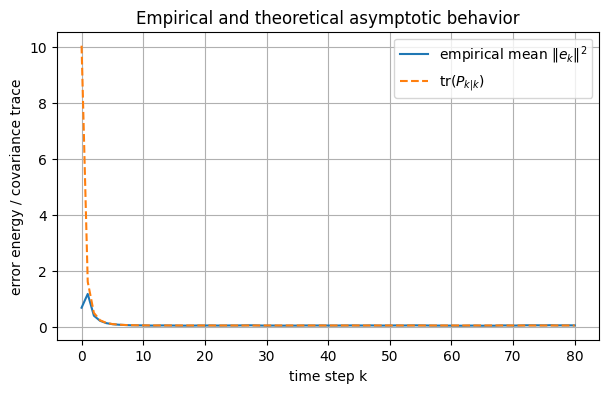

In [16]:
MC = 300
empirical_trace = np.zeros(T + 1)
theoretical_trace = np.array([np.trace(P_upd[k]) for k in range(T + 1)])

for trial in range(MC):
    x = x0.copy()
    xhat = xhat0.copy()
    P = P0.copy()

    errs = []

    for k in range(T + 1):
        vk = np.random.multivariate_normal(np.zeros(m), R).reshape(m, 1)
        y = C @ x + vk

        S = C @ P @ C.T + R
        K = P @ C.T @ np.linalg.inv(S)
        xhat = xhat + K @ (y - C @ xhat)
        P = (np.eye(n) - K @ C) @ P

        e = x - xhat
        errs.append(float((e.T @ e)[0,0]))

        if k < T:
            wk = np.random.multivariate_normal(np.zeros(n), Q).reshape(n, 1)
            x = A @ x + wk
            xhat = A @ xhat
            P = A @ P @ A.T + Q

    empirical_trace += np.array(errs)

empirical_trace /= MC


plt.figure(figsize=(7, 4))
plt.plot(range(T+1), empirical_trace, label="empirical mean $\|e_k\|^2$")
plt.plot(range(T+1), theoretical_trace, "--", label=r"$\mathrm{tr}(P_{k|k})$")
plt.xlabel("time step k")
plt.ylabel("error energy / covariance trace")
plt.title("Empirical and theoretical asymptotic behavior")
plt.legend()
plt.grid(True)
plt.show()


## 5. Takeaway

This example shows the main asymptotic features of the linear Kalman filter:

1. The covariance sequence \(P_{k|k}\) converges.
2. The gain \(K_k\) converges to a steady-state gain.
3. The influence of the initial condition fades away.
4. The estimation error settles into stationary second-order statistics.

In the time-invariant detectable/stabilizable case, this limiting behavior is described by the **discrete algebraic Riccati equation**. The corresponding steady-state filter is the asymptotic Kalman filter.
